
# GGLASSO Data Gen with My Algorithm Solver -- Adjacency Remains Fixed


In [1]:
# sphinx_gallery_thumbnail_number = 2

from gglasso.helper.data_generation import generate_precision_matrix, group_power_network, sample_covariance_matrix
from gglasso.problem import glasso_problem
from gglasso.helper.basic_linalg import adjacency_matrix
from estimate_connectivity import estimate_graph_connectivity, printPretty, freeze_part_1_test_part_2

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import rankdata 

p = 3
N = 20
SNR_dB = 25

Sigma, Theta = generate_precision_matrix(p=p, M=1, style='erdos', prob=0.2, seed=1234)


In [2]:
def sample_covariance_matrix(Sigma, N, seed=None, deterministic=False):
    """
    Samples data for a given covariance matrix Sigma (with K layers).
    Returns: sample covariance matrix S and the sampled data.
    """
    if deterministic:
        rng = None
    else:
        rng = np.random.default_rng(seed)

    if len(Sigma.shape) == 2:
        # Case for a single covariance matrix
        assert abs(Sigma - Sigma.T).max() <= 1e-10
        (p, p) = Sigma.shape
        
        if deterministic:
            # Generate predefined deterministic samples
            predefined_samples = np.tile(np.arange(p), (N, 1)).T  # Shape: (p, N)
            sample = np.linalg.cholesky(Sigma) @ predefined_samples
        else:
            sample = rng.multivariate_normal(np.zeros(p), Sigma, N).T
            
        S = np.cov(sample, bias=True)
        
    else:
        # Case for multiple covariance matrices
        assert abs(Sigma - np.transpose(Sigma, axes=(0, 2, 1))).max() <= 1e-10
        (K, p, p) = Sigma.shape

        sample = np.zeros((K, p, N))
        for k in np.arange(K):
            if deterministic:
                # Generate predefined deterministic samples for each layer
                predefined_samples = np.tile(np.arange(p), (N, 1)).T  # Shape: (p, N)
                sample[k, :, :] = np.linalg.cholesky(Sigma[k, :, :]) @ predefined_samples
            else:
                sample[k, :, :] = rng.multivariate_normal(np.zeros(p), Sigma[k, :, :], N).T
    
        S = np.zeros((K, p, p))
        for k in np.arange(K):
            S[k, :, :] = np.cov(sample[k, :, :], bias=True)
            
    return S, sample

In [3]:
# Add noise to the graph signal
def add_noise_to_y(data):
    # generate a noise vector for the graph signal, a N x 1 vector with gaussian noise 0 mean 1 variance for every sample

    N , M = data.shape

    for i in range(M):
        cur_sample = data[:, i]
        # calculate the power of the signal
        signal_power = np.linalg.norm(cur_sample, 2)**2 / N

        sigma_noise = signal_power * (10**(-SNR_dB / 10))

        noise = np.random.normal(0, sigma_noise, N)
        
        data[:, i] = data[:, i] + noise


    return data

In [4]:
def dynamic_scaling_y(data_dyn, scaling_factor=1.0001):
    # generate a noise vector for the graph signal, a N x 1 vector with gaussian noise 0 mean 1 variance for every sample

    N , M = data_dyn.shape

    # expponential scaling factor, see if this does not blow up

    for i in range(M):
        if i == 0:
            pass
        else:
            # last_sample = data_dyn[:, i-1]
            # last_sample = last_sample * scaling_factor
            data_dyn[:, i] = data_dyn[:, i] * scaling_factor**i

    return data_dyn

In [5]:
def draw_adjacency(Theta, Y):
    A = adjacency_matrix(Theta)

    printPretty(A)

    G = nx.from_numpy_array(A)
    pos = nx.drawing.layout.spring_layout(G, seed = 1234)

    labels = {i: round(Y[i, 0],2) for i in range(len(Y))}

    plt.figure()
    nx.draw_networkx(G, pos = pos, node_color = "darkblue", edge_color = "darkblue", font_color = 'red', font_size=20, labels=labels, with_labels = True)


In [6]:
def create_A_tensor_noNoise(A):
    # create the A_tensor
    for i in range(SAMPLES):
        if i == 0:
            A_tensor = A.astype(float)  
        else:
            A_tensor = np.dstack((A_tensor, A))
    # print(A_tensor.shape)
    return A_tensor

def add_noise_to_A_tensor(sample, A):
    # Turn the adjacency matrix into a tensor, one adjacency per M

    N, M = sample.shape

    for i in range(M):
        # A = adjacency_matrix(Theta)
        if i == 0:
            A_tensor = A.astype(float)  
        else:
            A_tensor = np.dstack((A_tensor, A))

    # check the shape of the tensor
    # print("A_tensor shape: ", A_tensor.shape)

    # Add noise to the state matrix -- the adjacency based on the SNR previously
    for i in range(M):
        cur_A = A_tensor[:, :, i]
        
        signal_power = np.linalg.norm(cur_A, 2)**2 / N

        sigma_noise = signal_power * (10**(-SNR_dB / 10))

        noise = np.random.normal(0, sigma_noise, (N,N))

        A_tensor[:, :, i] = A_tensor[:, :, i] + noise

        printPretty(A_tensor[:, :, i])
    
    return A_tensor


    0        0        0    
    0        0        1.00 
    0        1.00     0    
True Adjacency Matrix:


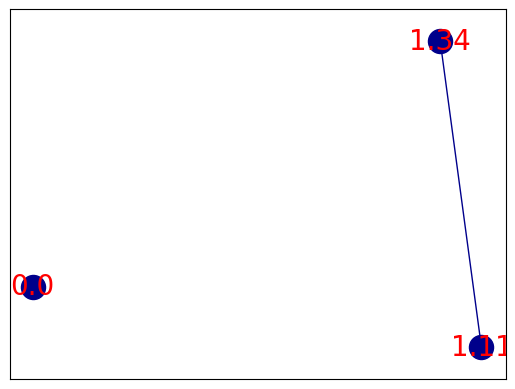

In [7]:
# Now running my algorithm to recognize graph topology

from estimate_connectivity import estimate_graph_connectivity

NODES = p
SAMPLES = N
EPSILON = 1e-10
VALUE_THRESHOLD = 1e10
ALPHA = 0.9
SCALING = 1.01 # scaling factor for dynamic scaling of graph signals
lambda_param = 0.1
alpha = 0.95

noise_on_y = True # ALWAYS TRUE otherwise singular matrix
noise_on_Adj = False # True or False depending on scenario difficulty
dynamic_scaling_of_data = False # If false, then in static scenario

Q_initial = np.eye(NODES*NODES) 
R_initial = np.eye(NODES)
H_initial = np.random.randn(NODES, NODES*NODES) 
F_initial = np.random.randn(NODES*NODES, NODES*NODES)


# Generate the samples
S, sample = sample_covariance_matrix(Sigma, N, deterministic=True)

Y = sample[:NODES, :SAMPLES] # should already be of these dimensions but just to check

# Display the true adjacency 
draw_adjacency(Theta, Y)

print("True Adjacency Matrix:")
# get the true adjacency
A = adjacency_matrix(Theta)



In [8]:
print("UNDER DYNAMIC? ", dynamic_scaling_of_data)

print("Origional Samples Prior to Any Processing:")
printPretty(sample)


if noise_on_Adj:
    print("NOISE ON ADJ: adding noise to adjacency")
    A_tensor = add_noise_to_A_tensor(sample, A)
else:
    print("NOISE ON ADJ: there is no noise on the adjacency")
    A_tensor = create_A_tensor_noNoise(A)


Y_nonoise = Y 

if noise_on_y:
    print("NOISE ON Y: adding noise to the graph signal")
    Y = Y + 0.1*np.random.randn(p, N)
    printPretty(Y)


if dynamic_scaling_of_data:
    # Dynamic scaling of the samples if that is the experiment being run
    print("Scaling the dynamic samples: ")
    Y = dynamic_scaling_y(Y, SCALING)
    printPretty(Y)
    # print("Dynamic scaling of Y data, parts 1 and 3 are fixed. Part 2 is estimated.")
    scal_fac = SCALING
    # A_estimated = freeze_part_1_test_part_2_dynamicScalingGrSignal(Y, A_tensor, scal_fac, lambda_param, alpha, Q_initial, R_initial, F_initial, H_initial)
    A_estimated, groundtr_H_optimals = freeze_part_1_test_part_2(Y, Y_nonoise, A_tensor, lambda_param, alpha, Q_initial, R_initial, F_initial, H_initial)
else:
    A_estimated, groundtr_H_optimals = freeze_part_1_test_part_2(Y, Y_nonoise, A_tensor, lambda_param, alpha, Q_initial, R_initial, F_initial, H_initial)

# for i in range(SAMPLES):
    # print(f"Time Step {i}")
    # printPretty(A_estimated[:, :, i])

    # print("Comparing to the given input adjacency")
    # printPretty(A_tensor[:, :, i])

print(f"Time Step {N-1}")
printPretty(A_estimated[:, :, -1])
print("Comparing to the given input adjacency")
printPretty(A_tensor[:, :, -1])

UNDER DYNAMIC?  False
Origional Samples Prior to Any Processing:
    0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0        0    
    1.34     1.34     1.34     1.34     1.34     1.34     1.34     1.34     1.34     1.34     1.34     1.34     1.34     1.34     1.34     1.34     1.34     1.34     1.34     1.34 
    1.11     1.11     1.11     1.11     1.11     1.11     1.11     1.11     1.11     1.11     1.11     1.11     1.11     1.11     1.11     1.11     1.11     1.11     1.11     1.11 
NOISE ON ADJ: there is no noise on the adjacency
NOISE ON Y: adding noise to the graph signal
   -0.07     0.05     0.05     0.01    -0.06    -0.02    -0.08    -0.02     0.07     0.08    -0.04    -0.09    -0.13    -0.04     0.25     0.06     0.08    -0.13     0.05    -0.06 
    1.51     1.32     1.50     1.32     1.31     1.31     1.35     1.23     1.39     1.38     1.68     1.52     1.16 

In [9]:
A_estimated = estimate_graph_connectivity(Y, lambda_param, alpha, Q_initial, R_initial, F_initial, H_initial, ground_truth_H=groundtr_H_optimals)

for i in range(SAMPLES):
    print(f"Time Step {i}")
    printPretty(A_estimated[:, :, i])

    print("Comparing to the given input adjacency")
    printPretty(A_tensor[:, :, i])

-----------------EST GR CONNECTIVITY-----------------
M is ...   20
Processing time step 3...
   Processing part 1
Calculating optimal F and H...
H_initial given as ground truth
    0        0        0        0        0        0        0        0        0    
    0        0        0        0        0        0.67     0        0.67     0    
    0        0        0        0        0        0.55     0        0.55     0    
H_optimal:
   -0.01    -0.00    -0.01     0.01    -0.00     0.02    -0.00     0.00     0.00 
    0.01     0.19     0.30    -0.31    -0.05     0.14     0.42     0.55     0.06 
   -0.01     0.15     0.23    -0.23    -0.04     0.15     0.33     0.46     0.05 
   Processing part 2
H_optimal is
    0        0        0        0        0        0        0        0        0    
    0        0.19     0.30    -0.31     0        0.14     0.42     0.55     0.06 
    0        0.15     0.23    -0.23     0        0.15     0.33     0.46     0    
   Processing part 3
Processing time st